# Gliquid Binary Fitting Demo

This notebook walks through the core workflow of the `gliquid` package:

1. Load elemental thermodynamic constants, digitized MPDS phase diagrams, and DFT convex hull entries from the Materials Project.
2. Explore the raw data and understand how it is structured.
3. Run the Nelder-Mead optimizer to find liquid non-ideal mixing parameters for a binary system.
4. Visualize the fitted phase diagram, the convex-hull energy landscape, and the optimizer path.
5. Batch fit and compare results across multiple systems.


In [ ]:
## UNCOMMENT THIS BLOCK FOR GOOGLE COLAB
# !git clone https://github.com/willwerj/gliquid_python.git
# %cd /content/gliquid_python
# !pip install -q .
# from pathlib import Path
# import gliquid.config as cfg
# cfg.set_data_dir(Path("/content/gliquid_python/data").resolve())

In [ ]:
import os
import gliquid.config as cfg

# By default cfg.project_root and cfg.data_dir are resolved from the installed package location.
# Override them here if your data lives elsewhere:
#   cfg.set_project_root("path/to/G_liquid")
#   cfg.set_data_dir("path/to/matrix_data")
print(f"Project root : {cfg.project_root}")
print(f"Data directory: {cfg.data_dir}")

# Materials Project API key — required for fetching DFT convex hull data.
# Replace with your own key from https://materialsproject.org/api
os.environ["NEW_MP_API_KEY"] = "YOUR_API_KEY_HERE"


## 1 - Loading binary data

`gliquid.load_binary_data` provides backend utilities for reading:
- **Measured elemental data** (melting enthalpy, melting temperature, boiling temperature) from JSON files in `cfg.data_dir`.
- **Digitized experimental phase diagrams** stored as MPDS-format JSON files (one per binary system).
- **DFT-calculated phase data** fetched from the Materials Project via `mp-api`.

MPDS phase diagrams are stored as SVG paths — essentially collections of curves that trace phase boundaries. The annotated figure below shows the anatomy of one such file.

<img src="../assets/digitized_pd_anatomy.png" style="max-width: 700px; width: 100%; height: auto;">


In [5]:
import gliquid.load_binary_data as lbd

# Elemental reference data loaded at import time from JSON files in cfg.data_dir
print("Melting temperatures (K)  :", lbd.melt_temps)
print("Melting enthalpies (J/mol):", lbd.melt_enthalpies)
print()

# Load Cu-Mg MPDS data: returns the raw JSON, per-component thermodynamic constants,
# and the digitized liquidus curve as a list of [X (at. frac. Mg), T (K)] points.
cu_mg_json, cu_mg_component_data, (cu_mg_digitized_liquidus, is_partial) = lbd.load_mpds_data('Cu-Mg')

print("Component data (Elt: [H_fusion (J/mol), T_fusion (K)]):")
print(" ", cu_mg_component_data)
print(f"Digitized liquidus ({len(cu_mg_digitized_liquidus)} points):")
print(" ", cu_mg_digitized_liquidus[:3], "...")
print()

# Identify solid phases from the MPDS JSON.
# 'lc' = line compound (no solid solubility), 'ss' = solid solution.
identified_cu_mg_phases = lbd.identify_mpds_phases(cu_mg_json)
print("Cu-Mg solid phases:")
for phase in identified_cu_mg_phases:
    print(" ", phase)


Melting temperatures (K)  : {'Al': 933.5, 'Ag': 1234.93, 'Fe': 1811, 'Ti': 1943, 'Ni': 1728, 'Cr': 2180, 'Cu': 1357.77, 'Zr': 2127, 'Nb': 2750, 'Zn': 692.7, 'Sn': 505.1, 'Si': 1687, 'Ca': 1115, 'Na': 370.9, 'Mg': 923, 'K': 336.7, 'Mn': 1519, 'Ba': 1000, 'Sr': 1050, 'V': 2183, 'Rb': 312.45, 'Ce': 1071, 'Nd': 1294, 'La': 1193, 'Y': 1795, 'Co': 1768, 'Sc': 1814, 'Li': 453.65, 'Ga': 302.9, 'Pb': 600.7, 'B': 2350, 'Th': 2023, 'Pr': 1204, 'Sm': 1347, 'Gd': 1586, 'Dy': 1685, 'Er': 1802, 'Yb': 1092, 'Hf': 2506, 'Cs': 301.7, 'Be': 1560, 'U': 1408, 'Ta': 3290, 'Eu': 1095, 'As': 1090, 'Ge': 1211.4, 'W': 3687, 'Ho': 1747, 'Mo': 2895, 'Tb': 1629, 'Tl': 577, 'Lu': 1936, 'Tm': 1818, 'In': 429.75, 'Sb': 903.778, 'Cd': 594.219, 'Hg': 234.321, 'Se': 494, 'Pd': 1828, 'Bi': 544.556, 'Pt': 2041.4, 'Au': 1337.33, 'Os': 3306, 'Te': 722.66, 'Ru': 2606, 'Ir': 2719, 'Rh': 2236, 'Re': 3458, 'Pu': 913, 'Pm': 1315, 'C': 4762}
Melting enthalpies (J/mol): {'Al': 10710, 'Ag': 11300, 'Fe': 13810, 'Ti': 14150, 'Ni': 17

`get_dft_convexhull` queries the Materials Project and returns a pymatgen `PhaseDiagram` object representing the T = 0K DFT ground-state convex hull. Results are cached locally after the first call.


In [6]:
from pymatgen.analysis.phase_diagram import PDPlotter

# Fetch (and cache) the DFT T=0K convex hull for Cu-Mg
cu_mg_dft_ch, _ = lbd.get_dft_convexhull('Cu-Mg', verbose=True)

cu_mg_pdp = PDPlotter(cu_mg_dft_ch)
fig = cu_mg_pdp.get_plot()
fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", width=750, height=600)
fig.show()


Using DFT entries solved with GGA functionals.
Loading cached DFT entry data.
2 stable line compound(s) on the DFT convex hull.


## 2 - Fitting the liquid free energy for a single binary system

`BinaryLiquid.from_cache()` assembles all of the above - MPDS data, DFT convex hull, and elemental constants - into a single object ready for fitting.

`fit_parameters()` then:
1. Identifies invariant points (eutectics, peritectics, congruent melting) from the liquidus and solid-phase data.
2. Filters to those that have matching DFT compounds.
3. Ranks constraint combinations by viability and runs Nelder-Mead optimization for each.

The diagrams below illustrate how invariant points on the phase diagram translate into thermodynamic constraints on the mixing parameters.

<img src="../assets/invariant_points_and_reactions.png" style="max-width: 100%; height: 480px; object-fit: contain; object-position: left center; display: block; margin: 0 !important;">



Cu: H_fusion = 13260 J/mol, T_fusion = 1357.77 K
Mg: H_fusion = 8480 J/mol, T_fusion = 923 K

Reading MPDS json from entry at https://mpds.io/entry/C906729...


--- Low temperature phase mismatch ---
MPDS: [||||||                           |                                |                                  ]
MP:   [                                 |                                |                                  ]
COMP:  0         10        20        30        40        50        60        70        80        90        100
--- Low temperature phases including component solid solutions ---
{'type': 'ss', 'name': '(Cu)', 'comp': 0.000381243, 'cbounds': [[0.000381243, 673.505], [0.0669068, 994.389]], 'tbounds': [[0.000381243, 673.505], [0.000381243, 1352.52]]}
{'type': 'lc', 'name': 'MgCu2', 'comp': 0.332825, 'tbounds': [[0.332825, 673.15], [0.332825, 1086.657]]}
{'type': 'lc', 'name': 'Mg2Cu', 'comp': 0.6666030000000001, 'tbounds': [[0.6666030000000001, 673.15], [0.6666030000000001, 83

No arguments specified for 't_vals', setting 't_units' to 'K'


C:\Users\willwerj\University of Michigan Dropbox\Joshua Willwerth\WHSun_Lab\G_liquid\gliquid_python\src\gliquid\binary.py:1501: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



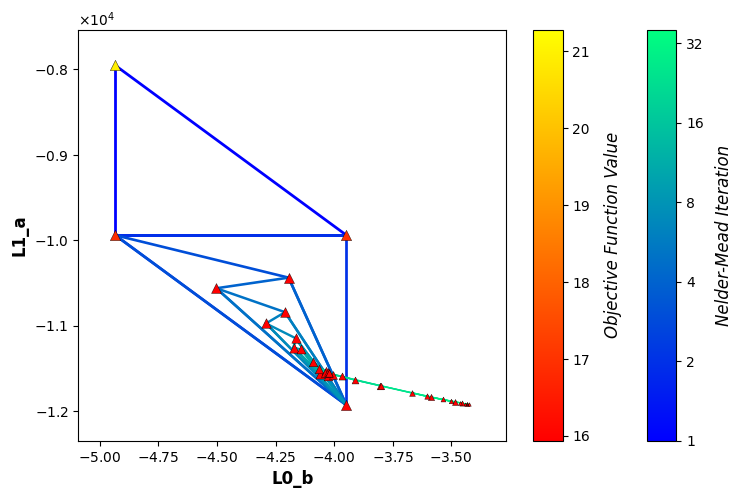

In [7]:
from gliquid.binary import BinaryLiquid, BLPlotter

param_format = 'comb-exp'  # options: 'linear', 'combined', 'comb-exp'

cu_mg_system = BinaryLiquid.from_cache('Cu-Mg', param_format=param_format)

# n_opts controls how many constraint combinations are explored; higher values are slower but more thorough
fit_results = cu_mg_system.fit_parameters(verbose=True, n_opts=5)
best_fit = min(fit_results, key=lambda x: x.get('mae', float('inf')), default={})

print("\n--- Cu-Mg fitting results ---")
for field, value in best_fit.items():
    print(f"  {field.upper():12s}: {value:.3f}" if isinstance(value, float) else f"  {field.upper():12s}: {value}")

cu_mg_plotter = BLPlotter(cu_mg_system)
cu_mg_plotter.show('fit+liq')   # Fitted liquidus vs. digitized experimental data
cu_mg_plotter.show('ch+g')      # T=0K DFT convex hull with overlaid liquid G curves
cu_mg_plotter.show('nmp')       # Nelder-Mead optimization path through parameter space


## 3 - Batch fitting across multiple binary systems

Results are cached to a JSON file after the first run. Delete the cache file to force a re-fit.


In [ ]:
import json
import numpy as np

systems_to_fit = ['C-Nb', 'Cr-Eu', 'Ag-V', 'Al-Cu']
cache_file = os.path.join(cfg.data_dir, f"fit_results_cache_{param_format}")

if os.path.exists(cache_file):
    with open(cache_file) as f:
        fitting_results = json.load(f)
    # Restore numpy arrays (not preserved by JSON serialization)
    for sys_results in fitting_results.values():
        sys_results['nmpath'] = np.array(sys_results.get('nmpath', []))
    print(f"Loaded cached results for: {list(fitting_results)}")
else:
    fitting_results = {}
    for sys_name in systems_to_fit:
        bl = BinaryLiquid.from_cache(sys_name, param_format=param_format)
        attempts = bl.fit_parameters(verbose=False, n_opts=3)
        fitting_results[sys_name] = min(attempts, key=lambda x: x.get('mae', float('inf')), default={})

    # Convert ndarray → list before serializing
    serializable = {k: {**v, 'nmpath': v.get('nmpath', np.array([])).tolist()}
                    for k, v in fitting_results.items()}
    with open(cache_file, 'w') as f:
        json.dump(serializable, f)
    print(f"Saved results to {cache_file}")


In [ ]:
import matplotlib.pyplot as plt

for sys_name, best_results in fitting_results.items():
    if not all(k in best_results for k in ['L0_a', 'L0_b', 'L1_a', 'L1_b']):
        print(f"{sys_name}: incomplete results, skipping")
        continue

    bl = BinaryLiquid.from_cache(sys_name, param_format=param_format)
    bl.update_params((best_results['L0_a'], best_results['L0_b'], best_results['L1_a'], best_results['L1_b']))
    bl.nmpath = np.array(best_results.get('nmpath', []))

    params_str = [float(f'{p:.2f}') for p in bl._params]
    print(f"\n{sys_name}  params={params_str}  MAE={best_results['mae']:.1f}K  MAPE={best_results['mape']:.2f}%")

    blp = BLPlotter(bl)
    # plt.show() is used here instead of blp.show() to ensure inline rendering in Jupyter
    blp.get_plot('nmp', plot_a_params=True); plt.show()
    blp.show('fit+liq')
    blp.show('ch+g')
